In [1]:
import torch
from glob import glob
import os
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [2]:
import torch
from glob import glob
import os
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import random
from sklearn.model_selection import train_test_split
from torchvision import transforms

# Global variables
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset_path = "DATA"  # Update the dataset path to point to the root folder
image_size = (224, 224)
num_classes = 3

# Define paths for train, validation, and test datasets
train_dir = os.path.join(dataset_path, "train")
# val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

# Data augmentation for training, resizing for validation and testing
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Custom dataset class
import os
from torch.utils.data import Dataset
from PIL import Image
from glob import glob

class CustomDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        # Match image files with common extensions
        self.image_paths = glob(os.path.join(self.folder_path, '*', '*.*'))
        self.image_paths = [path for path in self.image_paths if path.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp'))]
        self.labels = [self.get_label(path) for path in self.image_paths]
        self.labels_to_index = {label: index for index, label in enumerate(list(set(self.labels)))}

    def __getitem__(self, index):
        img_path = self.image_paths[index]
        img = Image.open(img_path).convert('RGB')
        label = self.labels[index]
        label_index = self.labels_to_index[label]

        if self.transform:
            img = self.transform(img)

        return img, label_index

    def __len__(self):
        return len(self.image_paths)

    def get_label(self, path):
        # Get folder name as label (assumes directory name is the label)
        return os.path.basename(os.path.dirname(path))


# Load datasets
train_dataset = CustomDataset(train_dir, transform=train_transform)
# val_dataset = CustomDataset(val_dir, transform=test_transform)
test_dataset = CustomDataset(test_dir, transform=test_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check device and dataset sizes
print(device)
print(f"Training set size: {len(train_dataset)}")
# print(f"Validation set size: {len(val_dataset)}")
print(f"Testing set size: {len(test_dataset)}")


cuda
Training set size: 15121
Testing set size: 300


In [3]:
num_classes=3

class CNN_Model(nn.Module):
    def __init__(self,num_classes):
        super(CNN_Model,self).__init__()
        
        self.conv1 = nn.Conv2d(3,32,kernel_size=4,stride=1,padding=0)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32,64,kernel_size=4,stride=1,padding=0)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64,128,kernel_size=4,stride=1,padding=0)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(128,128,kernel_size=4,stride=1,padding=0)
        self.bn4 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(kernel_size=3, stride=3)
        self.pool2= nn.MaxPool2d(kernel_size=3, stride=2)
        
        self.fc1 = nn.Linear(6*6*128,512)
        self.fc2 = nn.Linear(512,num_classes)
        
        self.flatten = nn.Flatten()
        self.relu = nn.ReLU() 
        self.dropout = nn.Dropout(0.5)
        
        
        
        
    def forward(self,x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
    
model = CNN_Model(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.0002)

In [4]:
from tqdm import tqdm

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []


best_score = float("inf")
n_epochs = 20
tolerance = 0

def train_epoch():
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    
    # Add tqdm to show progress bar for training
    for batch in tqdm(train_loader, desc="Training", leave=False):
        data = batch[0].to(device)
        labels = batch[1].to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels).item()
        total_predictions += labels.size(0)
        
    avg_loss = running_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    
    return avg_loss, accuracy

def eval_model():
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    
    # Add tqdm to show progress bar for validation
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating", leave=False):
            data = batch[0].to(device)
            labels = batch[1].to(device)
            
            outputs = model(data)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_predictions += torch.sum(preds == labels).item()
            total_predictions += labels.size(0)
            
    avg_loss = running_loss / len(test_loader)
    accuracy = correct_predictions / total_predictions
    
    return avg_loss, accuracy

def get_predictions_and_labels():
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Getting Predictions", leave=False):
            data = batch[0].to(device)  
            labels = batch[1].to(device)
            outputs = model(data)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

for epoch in range(n_epochs):
    print(f"Epoch {epoch},   ", end="")
    
    # Add tqdm to the epoch loop for progress tracking
    avg_train_loss, train_accuracy = train_epoch()
    avg_eval_loss, eval_accuracy = eval_model()
    
    if avg_eval_loss < best_score:
        best_score = avg_eval_loss
        torch.save(model.state_dict(), f"cnn_model{epoch+1}.pt")
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 8:
            break
            
    train_losses.append(avg_train_loss)
    val_losses.append(avg_eval_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(eval_accuracy)
    
    print(f"Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy * 100:.2f}%")
    print(f"Eval Loss: {avg_eval_loss:.4f}, Eval Accuracy: {eval_accuracy * 100:.2f}%")
    print("#" * 70)


Epoch 0,   

Train Loss: 0.3043, Train Accuracy: 88.23%
Eval Loss: 0.3410, Eval Accuracy: 87.00%
######################################################################
Epoch 1,   

Train Loss: 0.2091, Train Accuracy: 92.24%
Eval Loss: 0.2914, Eval Accuracy: 91.33%
######################################################################
Epoch 2,   

Train Loss: 0.1801, Train Accuracy: 93.47%
Eval Loss: 0.3876, Eval Accuracy: 88.67%
######################################################################
Epoch 3,   

Train Loss: 0.1621, Train Accuracy: 93.95%
Eval Loss: 0.2397, Eval Accuracy: 93.00%
######################################################################
Epoch 4,   

...

Train Loss: 0.0968, Train Accuracy: 96.34%
Eval Loss: 0.2349, Eval Accuracy: 92.67%
######################################################################
Epoch 16,   

Train Loss: 0.0883, Train Accuracy: 96.73%
Eval Loss: 0.1070, Eval Accuracy: 95.33%
######################################################################
Epoch 17,   

Train Loss: 0.0903, Train Accuracy: 96.77%
Eval Loss: 0.2265, Eval Accuracy: 93.00%
######################################################################
Epoch 18,   

Train Loss: 0.0877, Train Accuracy: 96.75%
Eval Loss: 0.2276, Eval Accuracy: 92.67%
######################################################################
Epoch 19,   

Train Loss: 0.0844, Train Accuracy: 96.89%
Eval Loss: 0.2070, Eval Accuracy: 92.33%
######################################################################


<Figure size 2000x800 with 0 Axes>

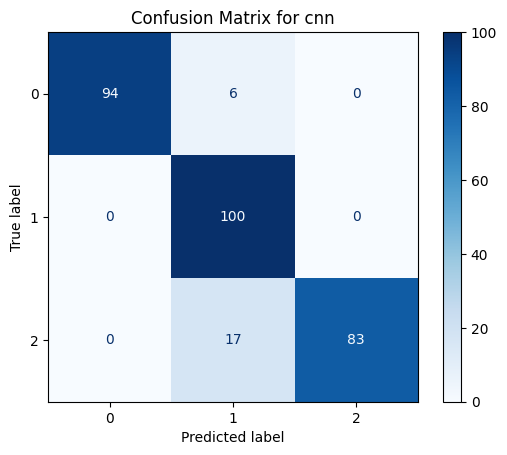

In [5]:
preds, true_labels = get_predictions_and_labels()
cm = confusion_matrix(true_labels, preds)
plt.figure(figsize=(20, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for cnn")
plt.show()


In [6]:
print("Classification Report for cnn:")
print(classification_report(true_labels, preds))

Classification Report for cnn:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       100
           1       0.81      1.00      0.90       100
           2       1.00      0.83      0.91       100

    accuracy                           0.92       300
   macro avg       0.94      0.92      0.92       300
weighted avg       0.94      0.92      0.92       300



device cuda


c:\Users\0871\.conda\envs\gpt2.3.11.11.2.18\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\0871\.conda\envs\gpt2.3.11.11.2.18\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Loss: 0.1593, Train Acc: 94.05%, Val Loss: 0.1525, Val Acc: 96.33%
Epoch 2: Train Loss: 0.0988, Train Acc: 96.32%, Val Loss: 0.1498, Val Acc: 95.67%
Epoch 3: Train Loss: 0.0826, Train Acc: 97.07%, Val Loss: 0.1189, Val Acc: 95.00%
Epoch 4: Train Loss: 0.0739, Train Acc: 97.35%, Val Loss: 0.0818, Val Acc: 96.33%
Epoch 5: Train Loss: 0.0624, Train Acc: 97.74%, Val Loss: 0.0645, Val Acc: 98.00%
Epoch 6: Train Loss: 0.0586, Train Acc: 97.86%, Val Loss: 0.0725, Val Acc: 98.33%
Epoch 7: Train Loss: 0.0568, Train Acc: 98.13%, Val Loss: 0.1476, Val Acc: 97.00%
Epoch 8: Train Loss: 0.0519, Train Acc: 98.20%, Val Loss: 0.1184, Val Acc: 96.00%
Epoch 9: Train Loss: 0.0521, Train Acc: 98.24%, Val Loss: 0.1230, Val Acc: 96.00%
Epoch 10: Train Loss: 0.0408, Train Acc: 98.48%, Val Loss: 0.0820, Val Acc: 98.67%


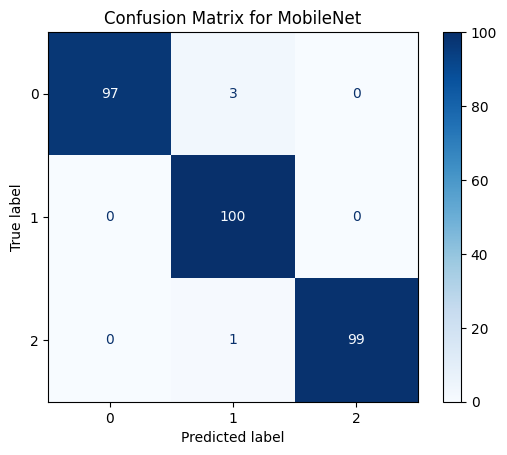

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       100
           1       0.96      1.00      0.98       100
           2       1.00      0.99      0.99       100

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


# Model definition
class MobileNetModel(nn.Module):
    def __init__(self, num_classes):
        super(MobileNetModel, self).__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier[1] = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.mobilenet(x)

# Initialize the model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device", device)
model = MobileNetModel(num_classes=3).to(device)  # Set num_classes appropriately
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0002)

def train_epoch():
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for batch in train_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_predictions += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

def eval_model(loader):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in loader:
            data = batch[0].to(device)
            labels = batch[1].to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_predictions += (preds == labels).sum().item()
            total_predictions += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct_predictions / total_predictions
    return avg_loss, accuracy

# Main training loop
best_score = float("inf")
n_epochs = 10
tolerance = 0

for epoch in range(n_epochs):
    train_loss, train_acc = train_epoch()
    val_loss, val_acc = eval_model(test_loader)

    if val_loss < best_score:
        best_score = val_loss
        torch.save(model.state_dict(), "mobilenet.pt")
        tolerance = 0
    else:
        tolerance += 1
        if tolerance >= 8:
            break

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

# Generate predictions and true labels
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        data = batch[0].to(device)
        labels = batch[1].to(device)
        outputs = model(data)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for MobileNet")
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds))


In [13]:
import torch
from torchvision import transforms
from PIL import Image
import os

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image transformations
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define the model class (same as the one used during training)
class MobileNetModel(nn.Module):
    def __init__(self, num_classes):
        super(MobileNetModel, self).__init__()
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier[1] = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.mobilenet(x)

# Load the trained model
model = MobileNetModel(num_classes=3)
model.load_state_dict(torch.load("mobilenet.pt"))
model = model.to(device)
model.eval()

def predict_image(image_path):
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB')
    image = image_transform(image).unsqueeze(0)  # Add batch dimension
    image = image.to(device)

    # Perform the prediction
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)

    return predicted.item()

# Helper function to map the prediction to label
def map_prediction_to_label(prediction):
    label_mapping = {0: "Pneumonia", 1: "Normal",2:"Tuberculosis"}
    return label_mapping.get(prediction, "Unknown")

# Example usage
image_path = r"DATA\test\Tuberculosis\CHNCXR_0655_1.png"
prediction = predict_image(image_path)
predicted_label = map_prediction_to_label(prediction)

print(f"The predicted label for the image is: {predicted_label}")


The predicted label for the image is: Normal
